In [2]:
import numpy as np

# Testing a little + trash can

In [17]:
data_1 = np.load("../data/scada_data_1.npz", allow_pickle=True)

In [18]:
print(data_1)

NpzFile '../data/scada_data_1.npz' with keys: sensor_readings, col_desc, sensor_readings_time, flow_unit


In [19]:
print(data_1["flow_unit"])

8


In [20]:
print(data_1["col_desc"])

[['pressure' '10' 'psi']
 ['pressure' '11' 'psi']
 ['pressure' '12' 'psi']
 ['pressure' '13' 'psi']
 ['pressure' '21' 'psi']
 ['pressure' '22' 'psi']
 ['pressure' '23' 'psi']
 ['pressure' '31' 'psi']
 ['pressure' '32' 'psi']
 ['pressure' '9' 'psi']
 ['pressure' '2' 'psi']
 ['flow' '10' 'cubic meter/hr']
 ['flow' '11' 'cubic meter/hr']
 ['flow' '12' 'cubic meter/hr']
 ['flow' '21' 'cubic meter/hr']
 ['flow' '22' 'cubic meter/hr']
 ['flow' '31' 'cubic meter/hr']
 ['flow' '110' 'cubic meter/hr']
 ['flow' '111' 'cubic meter/hr']
 ['flow' '112' 'cubic meter/hr']
 ['flow' '113' 'cubic meter/hr']
 ['flow' '121' 'cubic meter/hr']
 ['flow' '122' 'cubic meter/hr']
 ['flow' '9' 'cubic meter/hr']
 ['bulk_species_node' 'Chlorine @ 10' 'MG']
 ['bulk_species_node' 'Chlorine @ 11' 'MG']
 ['bulk_species_node' 'Chlorine @ 12' 'MG']
 ['bulk_species_node' 'Chlorine @ 13' 'MG']
 ['bulk_species_node' 'Chlorine @ 21' 'MG']
 ['bulk_species_node' 'Chlorine @ 22' 'MG']
 ['bulk_species_node' 'Chlorine @ 23' 'MG'

In [21]:
print(data_1["sensor_readings"])
#sensors 25-33 chlorine
#sensors 34-44 arsenic

[[126.85165  120.19229  117.086006 ...   0.         0.         0.      ]
 [127.79879  121.24273  118.18431  ...   0.         0.         0.      ]
 [128.83162  122.38834  119.31003  ...   0.         0.         0.      ]
 ...
 [133.22299  127.26107  125.39017  ...   0.         0.         0.      ]
 [120.56403  120.56403  125.185265 ...   0.         0.         0.      ]
 [119.99929  119.99929  124.55526  ...   0.         0.         0.      ]]


In [22]:
#get the indices/column numbers of the chlorine, flow, and arsenic sensors in the file

chlorine_sensors_indices = []
arsenic_sensors_indices = []
flow_sensors_indices = []
for i in range(0,len(data_1["col_desc"])):
    if "Chlorine" in data_1["col_desc"][i][1]:
        chlorine_sensors_indices.append(i)
    elif "AsIII" in data_1["col_desc"][i][1]:
        arsenic_sensors_indices.append(i)
    elif "flow" in data_1["col_desc"][i][0]:
        flow_sensors_indices.append(i)


In [23]:
chlorine_sensors_indices

[24, 25, 26, 27, 28, 29, 30, 31, 32]

In [24]:
print(data_1.files)

['sensor_readings', 'col_desc', 'sensor_readings_time', 'flow_unit']


In [25]:
#Get sensor readings of chlorine and flow sensors
cl_first = chlorine_sensors_indices[0]
cl_last = chlorine_sensors_indices[-1]
flow_first = flow_sensors_indices[0]
flow_last = flow_sensors_indices[-1]
cols = np.r_[cl_first:cl_last+1,
             flow_first:flow_last+1]
data_1_X_cl = data_1["sensor_readings"][:,cl_first:cl_last+1]
data_1_X_flow = data_1["sensor_readings"][:, flow_first:flow_last+1]

#first 9 columns in data_1 are chlorine sensors, the rest are flow sensors

In [26]:
#double check that amount of values is right
print(data_1_X_cl[0])
print(data_1_X_flow[0])

[0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 426.45697    307.60675     12.489316    59.691998    21.583134
   10.106865  -286.63446    100.92958    -10.2694235   -2.863221
   20.831396     1.5775098  426.45697  ]


In [27]:
as_first = arsenic_sensors_indices[0]
as_last = arsenic_sensors_indices[-1]
data_1_y = data_1["sensor_readings"][:, as_first:as_last+1]

In [28]:
print(data_1_y[0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
#Originally from cell 4, but replaced by function:


# for subdata in data:
#     all_cl_sensor_readings = []
#     for i in range (0, (NUMBER_CL_SENSORS)):
#         sensor_readings = subdata["X_cl_st"][:,i]
#         all_cl_sensor_readings.append(sensor_readings)
#     all_cl_sensor_readings = np.array(all_cl_sensor_readings)
#     subdata["all_cl_sensor_readings"] = all_cl_sensor_readings

# for subdata in data:
#     all_flow_sensor_readings = []
#     for i in range (0, (NUMBER_FLOW_SENSORS)):
#         sensor_readings = subdata["X_flow_st"][:,i]
#         all_flow_sensor_readings.append(sensor_readings)
#     all_flow_sensor_readings = np.array(all_flow_sensor_readings)
#     subdata["all_flow_sensor_readings"] = all_flow_sensor_readings

In [ ]:
#Originally from cell 7, but replaced by functions:

# z_p1 = get_last_readings(data[0]["X_cl_st_per_sensor"], 0, 11, 10)
# z_star_t = - np.sum([a * z for a, z in zip(Ais, z_p1)])
# z_t = data[0]["X_cl_st_per_sensor"][0][11]
# print(z_p1)
# print(z_star_t)
# print(z_t)
# compare_t = z_star_t - z_t
# print(compare_t)


# for i in range(0, len(data[0]["X_cl_st_per_sensor"])):
#     z_star_t = calculate_predicted_value(data[0]["X_cl_st_per_sensor"], i, 11, P, Ais)
#     z_t = data[0]["X_cl_st_per_sensor"][i][11]
#     compare_t = z_star_t - z_t
#     if compare_t > 0.5:  # Example threshold, adjust as needed
#         print(f"Anomaly detected at sensor {i} with predicted value {z_star_t} and actual value {z_t}")

In [ ]:
#maybe create a mean from all the flow sensors and just use that as a sensor?? That way, the flow won't have too much influence




chlor = []
flow = []

chlor_test = []
flow_test = []

flow_train_sorted = {}
chlorine_train_sorted_x = {}
chlorine_train_y = {}
train_set_sorted = {}


#get all possible combinations of flow readings, train set 

for file in range(len(train_set)):
    #print(train_set[i])
    for sensor in range(len(train_set[file]["X_flow_st_per_sensor"])):
        reading = 2
        while reading < (len(train_set[file]["X_flow_st_per_sensor"][sensor])-1):
            current_x_1 = train_set[file]["X_flow_st_per_sensor"][sensor][reading-2]
            current_x_2 = train_set[file]["X_flow_st_per_sensor"][sensor][reading-1]
            current_x = [current_x_1, current_x_2]
            if reading not in flow_train_sorted.keys():
                flow_train_sorted[reading] = [current_x]
            else:
                flow_train_sorted[reading].append(current_x)
            reading += 1
            
        #flow.append(train_set[i]["X_flow_st_per_sensor"][j])

for file in range(len(train_set)):
    for sensor in range(len(train_set[file]["X_cl_st_per_sensor"])):
        reading = 2
        while reading < (len(train_set[file]["X_cl_st_per_sensor"][sensor])-1):
            current_x_1 = train_set[file]["X_cl_st_per_sensor"][sensor][reading-2]
            current_x_2 = train_set[file]["X_cl_st_per_sensor"][sensor][reading-1]
            current_x = [current_x_1, current_x_2]
            if reading not in chlorine_train_sorted_x.keys():
                chlorine_train_sorted_x[reading] = [current_x]
            else:
                chlorine_train_sorted_x[reading].append(current_x)
            current_y = train_set[file]["X_cl_st_per_sensor"][sensor][reading]
            if reading not in chlorine_train_y.keys():
                chlorine_train_y[reading] = [current_y]
            else:
                chlorine_train_y[reading].append(current_y)
            reading += 1


# for i in range(len(test_set)):
#     for j in range(len(test_set[i]["X_flow_st_per_sensor"])):
#         flow_test.append(test_set[i]["X_flow_st_per_sensor"][j])
# for i in range(len(test_set)):
#     for j in range(len(test_set[i]["X_cl_st_per_sensor"])):
#         chlor_test.append(test_set[i]["X_cl_st_per_sensor"][j])


#print(chlor)
#print(flow[0])
#print(len(flow))


In [ ]:
#get all possible combinations of readings, test set 
flow_test_sorted = {}
chlorine_test_sorted_x = {}
chlorine_test_y = {}

for file in range(len(test_set)):
    #print(train_set[i])
    current_xs_file = []
    for sensor in range(len(test_set[file]["X_flow_st_per_sensor"])):
        reading = 2
        while reading < (len(test_set[file]["X_flow_st_per_sensor"][sensor])-1):
            current_x_1 = test_set[file]["X_flow_st_per_sensor"][sensor][reading-2]
            current_x_2 = test_set[file]["X_flow_st_per_sensor"][sensor][reading-1]
            current_x = [current_x_1, current_x_2]
            current_xs_file.append(current_x)
            reading += 1
    flow_test_sorted[file] = current_xs_file
    
            
        #flow.append(train_set[i]["X_flow_st_per_sensor"][j])

for file in range(len(test_set)):
    current_xs_file = []
    current_ys_file = []
    for sensor in range(len(test_set[file]["X_cl_st_per_sensor"])):
        reading = 2
        while reading < (len(test_set[file]["X_cl_st_per_sensor"][sensor])-1):
            current_x_1 = test_set[file]["X_cl_st_per_sensor"][sensor][reading-2]
            current_x_2 = test_set[file]["X_cl_st_per_sensor"][sensor][reading-1]
            current_x = [current_x_1, current_x_2]
            current_xs_file.append(current_x)

            
            current_y = test_set[file]["X_cl_st_per_sensor"][sensor][reading]
            current_ys_file.append(current_y)
            reading += 1
    
    chlorine_test_sorted_x[file] = current_xs_file
    chlorine_test_y[file] = current_ys_file

In [ ]:
full_x = []
full_y = []

LAST_file_INDEX = (len(chlorine_train_y.keys())-1)


#iterate through the readings
for chlorine_reading in range(2, LAST_READING_INDEX):
    #iterate through the sensors
    for sensor_index in range(len(chlorine_train_sorted_x[chlorine_reading])):
        #y value
        current_x = []
        current_y = chlorine_train_y[chlorine_reading][sensor_index]
        #iterate through the readings in the chlorine_x_sensor
        for precise_chlorine_reading in chlorine_train_sorted_x[chlorine_reading][sensor_index]:
            current_x.append(precise_chlorine_reading)
        #iterate through the readings in the flow_x_sensors
        for sensor_flow in flow_train_sorted[chlorine_reading]:
            for precise_flow_reading in sensor_flow:
                current_x.append(precise_flow_reading)
        full_x.append(current_x)
flow_test_sorted = {}
chlorine_test_sorted_x = {}
chlorine_test_y = {}

for file in range(len(test_set)):
    current_xs_file = []
    reading = 2
    while reading < (len(test_set[file]["X_flow_st_per_sensor"][0]) - 1):
            for sensor in range(len(test_set[file]["X_flow_st_per_sensor"])):
                current_x_1 = test_set[file]["X_flow_st_per_sensor"][sensor][reading - 2]
                current_x_2 = test_set[file]["X_flow_st_per_sensor"][sensor][reading - 1]
                current_x = [current_x_1, current_x_2]
                current_xs_file.append(current_x)
            reading += 1
    flow_test_sorted[file] = current_xs_file

for file in range(len(test_set)):
    current_xs_file = []
    current_ys_file = []

    reading = 2

    while reading < (len(test_set[file]["X_cl_st_per_sensor"][0]) - 1):
        for sensor in range(len(test_set[file]["X_cl_st_per_sensor"])):
            current_x_1 = test_set[file]["X_cl_st_per_sensor"][sensor][reading - 2]
            current_x_2 = test_set[file]["X_cl_st_per_sensor"][sensor][reading - 1]

            current_x = [current_x_1, current_x_2]
            current_xs_file.append(current_x)

            current_y = test_set[file]["X_cl_st_per_sensor"][sensor][reading]
            current_ys_file.append(current_y)

        reading += 1
    chlorine_test_sorted_x[file] = current_xs_file
    chlorine_test_y[file] = current_ys_file        full_y.append(current_y)   

In [ ]:


full_test_x = []
full_test_y = []

LAST_READING_INDEX = (len(chlorine_test_y.keys())-1)

#iterate through the readings
for chlorine_reading in range(2, LAST_READING_INDEX):
    #iterate through the sensors
    for sensor_index in range(len(chlorine_test_sorted_x[chlorine_reading])):
        #y value
        current_x = []
        current_y = chlorine_test_y[chlorine_reading][sensor_index]
        #iterate through the readings in the chlorine_x_sensor
        for precise_chlorine_reading in chlorine_test_sorted_x[chlorine_reading][sensor_index]:
            current_x.append(precise_chlorine_reading)
        #iterate through the readings in the flow_x_sensors
        for sensor_flow in flow_test_sorted[chlorine_reading]:
            for precise_flow_reading in sensor_flow:
                current_x.append(precise_flow_reading)
        full_test_x.append(current_x)
        full_test_y.append(current_y)   

In [ ]:
full_x = []
full_y = []

for file in range(len(chlorine_train_sorted_x)):
    for reading in range(len(chlorine_train_y[file])):
        for sensor in range(len(chlorine_train_y[reading])):
            current_y = chlorine_train_y[file][reading][sensor]
            current_xs = []
            for precise_chlorine_reading in chlorine_train_sorted_x[file][reading][sensor]:
                current_xs.append(precise_chlorine_reading)
            for sensor2 in range(len(flow_train_sorted[file][reading])):
                for precise_flow_reading in flow_train_sorted[file][reading][sensor2]:
                    current_xs.append(precise_flow_reading)
            full_x.append(current_xs)
            full_y.append(current_y)
            

In [ ]:
flow_train_sorted = {}
chlorine_train_sorted_x = {}
chlorine_train_y = {}

for file in range(len(train_set)):
    current_xs_file = []
    reading = 2
    while reading < (len(train_set[file]["X_flow_st_per_sensor"][0]) - 1):
        current_xs_reading = []
        for sensor in range(len(train_set[file]["X_flow_st_per_sensor"])):
            current_x_1 = train_set[file]["X_flow_st_per_sensor"][sensor][reading - 2]
            current_x_2 = train_set[file]["X_flow_st_per_sensor"][sensor][reading - 1]
            current_x = [current_x_1, current_x_2]
            current_xs_reading.append(current_x)
        reading += 1
        current_xs_file.append(current_xs_reading)

    flow_train_sorted[file] = current_xs_file

for file in range(len(train_set)):
    current_xs_file = []
    current_ys_file = []
    reading = 2
    while reading < (len(train_set[file]["X_cl_st_per_sensor"][0]) - 1):
        current_xs_reading = []
        current_ys_reading = []
        for sensor in range(len(train_set[file]["X_cl_st_per_sensor"])):
            current_xs_file_sensor = []
            
            current_x_1 = train_set[file]["X_cl_st_per_sensor"][sensor][reading - 2]
            current_x_2 = train_set[file]["X_cl_st_per_sensor"][sensor][reading - 1]

            current_xs_file_sensor = [current_x_1, current_x_2]
            current_xs_reading.append(current_xs_file_sensor)

            current_y = train_set[file]["X_cl_st_per_sensor"][sensor][reading]
            current_ys_reading.append(current_y)

        reading += 1

        current_xs_file.append(current_xs_reading)
        current_ys_file.append(current_ys_reading)

    chlorine_train_sorted_x[file] = current_xs_file
    chlorine_train_y[file] = current_ys_file

# Reading the files

In [1]:
#Cell 1
import numpy as np
import pandas as pd
data = []

#Iterate over the different numpy files
for i in range(1,21):
    chlorine_sensors = []
    flow_sensors = []
    arsenic_sensors = []
    X_cl = []
    X_flow = []
    y = []

    file_data = np.load(f"../data/scada_data_{i}.npz", allow_pickle=True)

    #Get the indices/column numbers of the chlorine, flow, and arsenic sensors in the file

    for j in range(0,len(file_data["col_desc"])):
        if "Chlorine" in file_data["col_desc"][j][1]:
            chlorine_sensors.append(j)
        elif "AsIII" in file_data["col_desc"][j][1]:
            arsenic_sensors.append(j)
        elif "flow" in file_data["col_desc"][j][0]:
            flow_sensors.append(j)

    #Get sensor readings of chlorine and flow sensors
    cl_first = chlorine_sensors[0]
    cl_last = chlorine_sensors[-1]
    flow_first = flow_sensors[0]
    flow_last = flow_sensors[-1]
    cols = np.r_[cl_first:cl_last+1,
                flow_first:flow_last+1]
    X_cl.append(file_data["sensor_readings"][:, cl_first:cl_last+1])
    X_flow.append(file_data["sensor_readings"][:, flow_first:flow_last+1])

    #Get sensor readings of arsenic sensors
    as_first = arsenic_sensors[0]
    as_last = arsenic_sensors[-1]
    y.append(file_data["sensor_readings"][:, as_first:as_last+1])

    data.append({"file": file_data, 
                 "Cl_sensors": chlorine_sensors, 
                 "Flow_sensors": flow_sensors, 
                 "As_sensors": arsenic_sensors, 
                 "X_cl": X_cl, 
                 "X_flow": X_flow, 
                 "y": y})

# Final remarks

Since all the values of each file are finally saved in various lists, inside a dictionary inside the data list, you have to cal them like this:

data[i]["xxxxxx"][0][j]

i is the file you want (counting starts at 0, so scada_data_1 is in data[0])  
"xxxxxx" is the part of the data you want  
Since every value is inside a list with one entry, you always have to use [0]  
j is the value/row (depending on the object)  
* for "file", "X_cl", "X_flow", and "y", it is the row
* for "Cl_sensors", "Flow_sensors", and "As_sensors", it is the value (there is only 1 row)

# Data standardization

    

In [2]:
#Cell 2
#calculate means and standard deviations for chlorine, flow, and arsenic sensor readings across all files
cl_all = []
as_all = []
flow_all = []

for i in range(0,20):
    cl_all.append(data[i-1]["X_cl"][0])
    flow_all.append(data[i-1]["X_flow"][0])
    as_all.append(data[i-1]["y"][0])
    
cl_all = np.concatenate(cl_all, axis=0)
flow_all = np.concatenate(flow_all, axis=0)
as_all = np.concatenate(as_all, axis=0)
cl_mean = np.mean(cl_all)
flow_mean = np.mean(flow_all)
as_mean = np.mean(as_all)
cl_std = np.std(cl_all)
flow_std = np.std(flow_all)
as_std = np.std(as_all)

In [3]:
#Cell 3
# standardize the chlorine, flow, and arsenic sensor readings in each file
# standardization formula: Z(t) = X(t) - µ / σ (Detecting Changes in Water Quality Data)

def standardize(unst_data, mean, std):
    st_data = np.zeros(unst_data.shape)
    for j in range(0, len(unst_data)):
        for k in range(0, len(unst_data[j])):
            st_data[j][k] = (unst_data[j][k] - mean) / std  
    return st_data

for i in range(0,20):
    
    X_cl_st = standardize(data[i]["X_cl"][0], cl_mean, cl_std)
    X_flow_st = standardize(data[i]["X_flow"][0], flow_mean, flow_std)
    y_st = standardize(data[i]["y"][0], as_mean, as_std)

    data[i]["X_cl_st"] = X_cl_st
    data[i]["X_flow_st"] = X_flow_st
    data[i]["y_st"] = y_st

# Linear predictor

Step-wise list:

* Get readings per sensor (Cell 4)
* Implement the equation, without the coefficents (main part)
* Set window size (P), maybe 10?
* Implement the second algorithm mentioned (autocorrelation method of AR modeling, get unbiased coefficients)
* Combine the two algorithms

In [4]:
#Cell 4
#Get the values per chlorine and flow, and arsenic sensor
NUMBER_CL_SENSORS = len(chlorine_sensors)
NUMBER_FLOW_SENSORS = len(flow_sensors)
NUMBER_AS_SENSORS = len(arsenic_sensors) 

def get_readings_per_sensor(data, number_sensors, sensor_type):
    for subdata in data: 
        all_sensor_readings = []
        for i in range (0, (number_sensors)):
            sensor_readings = subdata[sensor_type][:,i]
            all_sensor_readings.append(sensor_readings)
        subdata[f"{sensor_type}_per_sensor"] = np.array(all_sensor_readings)
    
get_readings_per_sensor(data, NUMBER_CL_SENSORS, "X_cl_st")
get_readings_per_sensor(data, NUMBER_FLOW_SENSORS, "X_flow_st")
get_readings_per_sensor(data, NUMBER_AS_SENSORS, "y_st")

In [5]:
#Cell 5
#Get the last (10) readings of the X sensors

def get_last_readings(data, sensor, current_position, amount):
    return data[sensor][int(current_position - amount):int(current_position)]

In [6]:
#Cell 6
#Divide the data into training and test set (by scada data files)
#There are only about 10 sensors in each of the categories, which is why I will only split the sensors 
#in training and test set and not create a validation set
#2/3 training set, 1/3 test set

train_set = data[0:14]
test_set = data[14:20]


In [7]:
#Cell 7
#Calculate the equation (Z*(t) = -∑_{i=1}^{P} a_i · Z(P-1))

#Z*(t) is the predicted value for the next sensor reading
#P is the window size, i.e. the number of previous sensor readings used for the prediction, set to 10 here
#Z (P-1) is a representation of the previous sensor readings
#Ignored/set randomly for now:
#a_i is the coefficient (weight) for the i-th previous sensor reading, 
#which can be calculated using linear regression on the standardized sensor readings of the chlorine and flow sensors as input and the standardized sensor readings of the arsenic sensors as output.

P = 5
Ais = [0.2, 0.2, 0.2, 0.2, 0.2]  # Example coefficients, replace with actual values
Ais_arx = [0.2, 0.2, 0.2, 0.2, 0.2]

def calculate_predicted_value(data, sensor, current_position, window_size, coefficients):
    last_readings = get_last_readings(data, sensor, current_position, window_size)
    #print(str(sensor) + ": " + str(last_readings))
    z_star_t = np.sum([a * z for a, z in zip(coefficients, last_readings)])
    return z_star_t

def calculate_predicted_value_ARX(data1, data2, sensor, current_position, window_size, coefficients):
    last_readings_chlorine = get_last_readings(data1, sensor, current_position, window_size)
    last_readings_flow = []
    for i in range(len(data2)):
        last_readings_flow_i = get_last_readings(data2, i, current_position, window_size)
        last_readings_flow.append(last_readings_flow_i)
    mean_flow_sensor = []
    for i in range(len(last_readings_flow_i)):
        value_i = []
        for sensor in last_readings_flow:
            value_i.append(sensor[i])
        mean_flow_sensor.append(np.mean(value_i))
    #print(str(sensor) + ": " + str(last_readings))
    z_star_t = np.sum([a * z for a, z in zip(coefficients, last_readings_chlorine)] + [b * x for b, x in zip(coefficients, mean_flow_sensor)])
    return z_star_t

#z_star_t = calculate_predicted_value(data[0]["X_cl_st_per_sensor"], 0, 11, P, Ais)

def detect_anomalies(data, current_position, window_size, coefficients):
    predicted_values = []
    real_values = []
    anomalies = []
    for i in range(0, len(data)):
        z_star_t = calculate_predicted_value(data, i, current_position, window_size, coefficients)
        predicted_values.append(z_star_t)
        z_t = data[i][current_position]
        real_values.append(z_t) 
        if z_star_t - z_t > 0.5:  # Example threshold, adjust as needed
            #print(f"Anomaly detected at sensor {i} with predicted value {z_star_t} and actual value {data[i][current_position]}")
            anomalies.append({"sensor": i, "position": current_position, "predicted_value": z_star_t, "actual_value": z_t, "anomaly_size": z_star_t - z_t})
    return predicted_values, real_values, anomalies

def detect_anomalies_ARX(data1, data2, current_position, window_size, coefficients):
    predicted_values = []
    real_values = []
    anomalies = []
    for i in range(0, len(data1)):
        z_star_t = calculate_predicted_value_ARX(data1, data2, i, current_position, window_size, coefficients)
        predicted_values.append(z_star_t)
        z_t = data1[i][current_position]
        real_values.append(z_t) 
        if z_star_t - z_t > 0.5:  # Example threshold, adjust as needed
            #print(f"Anomaly detected at sensor {i} with predicted value {z_star_t} and actual value {data[i][current_position]}")
            anomalies.append({"sensor": i, "position": current_position, "predicted_value": z_star_t, "actual_value": z_t, "anomaly_size": z_star_t - z_t})
    return predicted_values, real_values, anomalies

#predicted_values_cl, real_values_cl, anomalies_cl = detect_anomalies(data[0]["X_cl_st_per_sensor"][:, 0:(len((data[0]["X_cl_st_per_sensor"][1])/2))], 11, P, Ais)
#predicted_values_flow, real_values_flow, anomalies_flow = detect_anomalies(data[0]["X_flow_st_per_sensor"], 11, P, Ais)

predicted_values_cl = []
real_values_cl = []
anomalies_cl = []
predicted_values_flow = []
real_values_flow = []
anomalies_flow = []

predicted_values_cl_arx = []
real_values_cl_arx = []
anomalies_cl_arx = []
as_values_arx = []

for data_i in train_set:
    predicted_values_cl_i, real_values_cl_i, anomalies_cl_i = detect_anomalies_ARX(data_i["X_cl_st_per_sensor"], data_i["X_flow_st_per_sensor"], 30, P, Ais)
   

    predicted_values_cl_arx.append(predicted_values_cl_i)
    real_values_cl_arx.append(real_values_cl_i)
    anomalies_cl_arx.append(anomalies_cl_i)
    

print("ARX_prediction: ", predicted_values_cl_arx[1])
print(real_values_cl_arx)

for data_i in train_set:
    
    predicted_values_cl_i, real_values_cl_i, anomalies_cl_i = detect_anomalies(data_i["X_cl_st_per_sensor"], 11, P, Ais)
    predicted_values_flow_i, real_values_flow_i, anomalies_flow_i = detect_anomalies(data_i["X_flow_st_per_sensor"], 11, P, Ais)
    as_values = data_i["y_st_per_sensor"][:, 11]

    predicted_values_cl.append(predicted_values_cl_i)
    real_values_cl.append(real_values_cl_i)
    anomalies_cl.append(anomalies_cl_i)
    predicted_values_flow.append(predicted_values_flow_i)
    real_values_flow.append(real_values_flow_i)
    anomalies_flow.append(anomalies_flow_i)
    as_values_arx.append(as_values)

print("Regular prediction: ", predicted_values_cl[1])
print("Real values: ", real_values_cl[1])
print("Arsenic values: ", as_values_arx[1])

#Datei 2
comparison_df = pd.DataFrame({"ARX_prediction: ": predicted_values_cl_arx[1], "Regular_prediction": predicted_values_cl[1], "real_value": real_values_cl_arx[1]})
print(comparison_df)
print(anomalies_cl_arx[1])
print(anomalies_cl[1])
#print(data[1]"y"][0][11])
# Conclusion: Works for now, but the negative sign in the equation should maybe be deleted
# Reason: The predicted value is very close to the actual value, but the negative sign in the equation 
# causes the predicted value to be negative, while the actual value is positive. 
# This makes the values be very different and the comparison value be very high (1,43 instead of 0).

ARX_prediction:  [np.float64(-0.45112983319335265), np.float64(-0.45112983319335265), np.float64(-0.45112983319335265), np.float64(0.3248082247061226), np.float64(-0.45112983319335265), np.float64(0.43841577837816803), np.float64(1.0108410623354407), np.float64(0.15154140856690135), np.float64(0.6057663124484511)]
[[np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(0.5090581774711609), np.float64(-0.7174538373947144), np.float64(0.6101557016372681)], [np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(0.5567278861999512), np.float64(-0.7174538373947144), np.float64(0.9467115998268127)], [np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(-0.71745383

In [9]:
print(-0.717454 * cl_std + cl_mean)
print(1.879907 * cl_std + cl_mean)

-2.2351742e-08
0.40644377


In [10]:
print(data[0]["X_cl_st_per_sensor"][0])

[-0.71745384 -0.71745384 -0.71745384 ... -0.71745384 -0.71745384
 -0.71745384]


In [65]:
#Cell 8
#Implement yule-walker equations to get coefficients
 
#from statsmodels.regression.linear_model import yule_walker
#coefficients = yule_walker(data[4]["X_cl_st_per_sensor"][0], order=5)
# print(coefficients)

#do not work because not enough data points/not enough variance
#Conclusion: Just keep default coefficients, value all preceding points the same way


In [7]:
from sklearn.linear_model import LinearRegression

In [16]:
#chlorine_train_y

In [17]:
#flow_train_sorted

In [18]:
#print(len(full_x))
#print(len(full_y))

In [8]:
X_train = []
y_train = []

for file in range(len(train_set)):

    chlor_data = train_set[file]["X_cl_st_per_sensor"]
    flow_data = train_set[file]["X_flow_st_per_sensor"]

    n_sensors = len(chlor_data)
    n_time = len(chlor_data[0]) 

    for sensor in range(n_sensors):

        for timestep in range(2, n_time):

            x = [
                chlor_data[sensor][timestep-2],
                chlor_data[sensor][timestep-1]
            ]

            for sensor2 in range(len(flow_data)):
                x.append(flow_data[sensor2][timestep-2])
                x.append(flow_data[sensor2][timestep-1])


            y = chlor_data[sensor][timestep]

            X_train.append(x)
            y_train.append(y)

In [19]:
#X_train

In [9]:
#x = np.column_stack([flow[0], chlor[0]])
#y = chlor[0]

#print(x)

reg = LinearRegression()
reg.fit(X_train, y_train)
#reg.score(full_x, full_y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[-0.06, 0.93, 0.02,..., 1.41, 0.02,-0.08]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.03816
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,26
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](28,)","[1441.25, 474.4 , 346.54,..., 0.87, 0. , 0. ]"


In [14]:
reg.score(X_train, y_train)

0.8227831810946042

In [15]:
print(reg.predict([X_train[0]]))
print(y_train[0])

[-0.67714448]
-0.7174538373947144


In [10]:
X_test = []
y_test = []

for file in range(len(test_set)):

    chlor_data = test_set[file]["X_cl_st_per_sensor"]
    flow_data = test_set[file]["X_flow_st_per_sensor"]

    n_sensors = len(chlor_data)
    n_time = len(chlor_data[0]) 

    for sensor in range(n_sensors):

        for timestep in range(2, n_time):

            x = [
                chlor_data[sensor][timestep-2],
                chlor_data[sensor][timestep-1]
            ]

            for sensor2 in range(len(flow_data)):
                x.append(flow_data[sensor2][timestep-2])
                x.append(flow_data[sensor2][timestep-1])


            y = chlor_data[sensor][timestep]

            X_test.append(x)
            y_test.append(y)

In [21]:
print(len(X_test))
print(len(y_test))

54378
54378


In [22]:
reg.score(X_test, y_test)

0.810773986124819

In [11]:
def detect_anom(pred_val, real_val, id):
    if abs(pred_val + real_val) > 0.5:
        #anomaly = "probable anomaly detected at", id
        return id, (pred_val - real_val)
    else:
        return [0,0,0], 0
    

In [ ]:
#What is yet to do
#Save the examples in a way that you can trace back where they come from so that you know where anomalies were detected -------Done
#connect all this to the actual arsenic values, see if this anomaly prediction actually predicts anomalies

In [12]:
X_test_2 = []
y_test_2 = []
as_y = []

for file in range(len(test_set)):

    chlor_data = test_set[file]["X_cl_st_per_sensor"]
    flow_data = test_set[file]["X_flow_st_per_sensor"]
    arsenic_data = test_set[file]["y"][0]

    n_cl_sensors = len(chlor_data)
    n_time = len(chlor_data[0]) 

    for cl_sensor in range(n_cl_sensors):

        for timestep in range(2, n_time):

            x = [
                chlor_data[cl_sensor][timestep-2],
                chlor_data[cl_sensor][timestep-1]
            ]

            for flow_sensor in range(len(flow_data)):
                x.append(flow_data[flow_sensor][timestep-2])
                x.append(flow_data[flow_sensor][timestep-1])

            y = chlor_data[cl_sensor][timestep]

            as_y_t = ([file, cl_sensor, timestep], arsenic_data[timestep])

            full_x = ([file, cl_sensor, timestep], x)
            X_test_2.append(full_x)
            y_test_2.append(([file, cl_sensor, timestep], y))
            as_y.append(as_y_t)

In [26]:
print(X_test_2[0])
print(y_test_2[0])
print(as_y[0])

([0, 0, 2], [np.float64(-0.7174538373947144), np.float64(-0.7174538373947144), np.float64(2.740403175354004), np.float64(2.713369846343994), np.float64(1.9345471858978271), np.float64(1.9286186695098877), np.float64(-0.3768030107021332), np.float64(-0.38424840569496155), np.float64(-0.12433931231498718), np.float64(-0.1180301308631897), np.float64(-0.3478794991970062), np.float64(-0.3538168668746948), np.float64(-0.418021023273468), np.float64(-0.42411595582962036), np.float64(-2.610398530960083), np.float64(-2.666902780532837), np.float64(0.19355285167694092), np.float64(0.18759965896606445), np.float64(-0.45684266090393066), np.float64(-0.504113495349884), np.float64(-0.48205217719078064), np.float64(-0.4792841374874115), np.float64(-0.31583157181739807), np.float64(-0.31739187240600586), np.float64(-0.4285677969455719), np.float64(-0.4412270188331604), np.float64(2.740403175354004), np.float64(2.713369846343994)])
([0, 0, 2], np.float64(-0.7174538373947144))
([0, 0, 2], array([0., 0

In [24]:
#X_test_2[0][1]

In [13]:
anomalies = []
anomalies_truth_values = {}
anomalies_truth_values["true"] = []
anomalies_truth_values["false"] = []

no_anomalies = []
no_anomalies_truth_values = {}
no_anomalies_truth_values["true"] = []
no_anomalies_truth_values["false"] = []

pred_vals_cl = []
real_vals_cl = []

for situation in range(len(X_test_2)):
    
    #put X_test into regression, get predicted value
    pred_cl_val = reg.predict(np.array(X_test_2[situation][1]).reshape(1, -1))
    pred_vals_cl.append(pred_cl_val)

    #get real value
    real_cl_val = y_test_2[situation][1]
    real_vals_cl.append(real_cl_val)

    #get id
    id = X_test_2[situation][0]

    #get actual as value in the system
    real_as_val = np.sum(as_y[situation][1])

    #get anomaly scores for the detected anomalies, threshold 0.5
    anom_id, anom_score = detect_anom(pred_cl_val, real_cl_val, id)

    if situation == 2:
        print("pred_cl_val: ", pred_cl_val)
        print("real_cl_val: ", real_cl_val)
        print("real_as_val: ", real_as_val)
        print("anom_score: ", anom_score )

    #save anomaly ids and scores, see whether there actually is an anomaly and save the comparison as a truth value
    if anom_id != [0,0,0]:
        anomalies.append((anom_id, anom_score))

        #true positives/sensitivity
        if real_as_val > 0:
            anomalies_truth_values["true"].append((anom_id, anom_score))
        #false positives/beta error
        else:
            anomalies_truth_values["false"].append((anom_id, anom_score))
    else:
        no_anomalies.append((anom_id, anom_score))

        #false negatives/alpha error
        if real_as_val > 0:
            no_anomalies_truth_values["false"].append(id)
        #true negatives/specificity
        else:
            no_anomalies_truth_values["true"].append(id)


#get absolute and relative frequencies of true positives, false positives, false negatives and true negatives

n_situations = len(X_test_2)


#true positives/sensitivity
tp = len(anomalies_truth_values["true"])
tp_rel = round(((tp/n_situations)*100), 2)

#false positives/alpha error
fp = len(anomalies_truth_values["false"])
fp_rel = round(((fp/n_situations)*100), 2)

#false negatives/beta error
fn = len(no_anomalies_truth_values["false"])
fn_rel = round(((fn/n_situations)*100), 2)

#true negatives/specificity
tn = len(no_anomalies_truth_values["true"])
tn_rel = round(((tn/n_situations)*100), 2)

#get conditional frequencies, sorted by as true or false

n_as_true = tp+fn
n_as_false = tn+fp

#tp/true
tp_true = round(((tp/n_as_true)*100), 2)

#fp/false
fp_false = round(((fp/n_as_false)*100), 2)

#fn/true
fn_true = round(((fn/n_as_true)*100), 2)

#tn/false
tn_false = round(((tn/n_as_false)*100), 2)


#create overview tables 
#H1: There is an arsenic contamination
#H0: There is no arsenic contamination 

#print("\n \n \n")
#absolute frequency
H1 = [tp, fn]
H0 = [fp, tn]

H1_H0 = [H1, H0]

df_abs = pd.DataFrame(H1_H0, index=["is positive", "is negative"], columns=["detected as positive", "detected as negative"])

print("Absolute frequencies: \n", df_abs, "\n \n")

#relative frequency
H1_rel = [tp_rel, fn_rel]
H0_rel = [fp_rel, tn_rel]

H1_H0_rel = [H1_rel, H0_rel]

df_rel = pd.DataFrame(H1_H0_rel, index=["is positive", "is negative"], columns=["detected as positive", "detected as negative"])

print("Relative frequencies (in percent): \n", df_rel, "\n \n")

#conditional frequencies
H1_cond = [tp_true, fn_true]
H0_cond = [fp_false, tn_false]
df_cond_true = pd.DataFrame(H1_cond, index=["Detected as positive", "Detected as negative"], columns=["is positive"])
print("Conditional frequencies for actual arsenic contamination (in percent): \n", df_cond_true, "\n \n")

H0_cond = [fp_false, tn_false]
df_cond_false = pd.DataFrame(H0_cond, index=["Detected as positive", "Detected as negative"], columns=["is negative"])
print("Conditional frequencies for no arsenic contamination (in percent): \n", df_cond_false, "\n \n")



pred_cl_val:  [-0.66937706]
real_cl_val:  -0.7174538373947144
real_as_val:  0.0
anom_score:  [0.04807678]
Absolute frequencies: 
              detected as positive  detected as negative
is positive                  3535                   227
is negative                 47754                  2862 
 

Relative frequencies (in percent): 
              detected as positive  detected as negative
is positive                  6.50                  0.42
is negative                 87.82                  5.26 
 

Conditional frequencies for actual arsenic contamination (in percent): 
                       is positive
Detected as positive        93.97
Detected as negative         6.03 
 

Conditional frequencies for no arsenic contamination (in percent): 
                       is negative
Detected as positive        94.35
Detected as negative         5.65 
 



In [14]:
import matplotlib.pyplot as plt


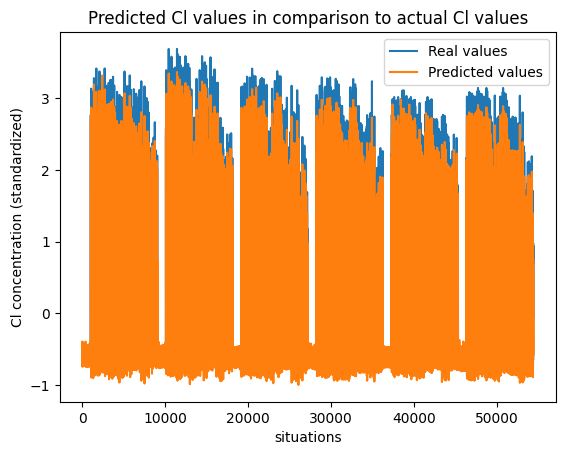

In [15]:
situations = np.array(list(range(len(real_vals_cl))))
plt.plot(situations ,np.array(real_vals_cl), label ="Real values")
plt.plot(situations, np.array(pred_vals_cl), label = "Predicted values")

plt.xlabel("situations")
plt.ylabel("Cl concentration (standardized)")
plt.title("Predicted Cl values in comparison to actual Cl values")
plt.legend()
plt.show()

In [16]:
differences = [real_vals_cl[i] - pred_vals_cl[i] for i in situations]
np.mean(np.array(differences))

np.float64(-0.00021973204036002155)

# Preliminary Discussion 

Results: 
- Model highly overpredicts arsenic contamination, especially in comparison to the rare occurrence of actual arsenic contaminations
- Not each arsenic contamination is predicted, 6.03 % of all arsenic predictions are not detected as positive
- Conditional frequencies separated by contamination status shows that the model does not seem to strongly differentiate by the contamination status

Possible explanations:

- Flow sensor readings directly before the chlorine value, that is supposed to be predicted are used (but flow needs time to influence chlorine). Possible solution: take flow readings from further in the past
- Chlorine value is constant most of the time, but the model does not seem to get that right. It constantly predicts something around -0.66, but the constant value is -0.71. Threshold is 0.5, so many constant chlorine values are mistakenly detected as positive. Possible solution: Set threshold a little higher, but then, even more actual arsenic contaminations will not be recognized (not an ideal solution)

Further examination:
- Diagram suggests that values themselves do not seem to be that bad, but they are usually too low, probably about 0.5. 
- bias term +0.5 might be helpful
- mean calculation suggests a much lower bias term (-0.00022) might be good, why?




In [24]:
#Test again (with bias term +0.5)

anomalies_bias = []
anomalies_truth_values_bias = {}
anomalies_truth_values_bias["true"] = []
anomalies_truth_values_bias["false"] = []

no_anomalies_bias = []
no_anomalies_truth_values_bias = {}
no_anomalies_truth_values_bias["true"] = []
no_anomalies_truth_values_bias["false"] = []

pred_vals_cl_bias = []
real_vals_cl_bias = []

for situation in range(len(X_test_2)):
    
    #put X_test into regression, get predicted value
    pred_cl_val_bias = reg.predict(np.array(X_test_2[situation][1]).reshape(1, -1)) + 0.5
    pred_vals_cl_bias.append(pred_cl_val_bias)

    #get real value
    real_cl_val_bias = y_test_2[situation][1]
    real_vals_cl_bias.append(real_cl_val_bias)

    #get id
    id_bias = X_test_2[situation][0]

    #get actual as value in the system
    real_as_val_bias = np.sum(as_y[situation][1])

    #get anomaly scores for the detected anomalies, threshold 0.5
    anom_id_bias, anom_score_bias = detect_anom(pred_cl_val_bias, real_cl_val_bias, id_bias)

    if situation == 2:
        print("pred_cl_val: ", pred_cl_val_bias)
        print("real_cl_val: ", real_cl_val_bias)
        print("real_as_val: ", real_as_val_bias)
        print("anom_score: ", anom_score_bias )

    #save anomaly ids and scores, see whether there actually is an anomaly and save the comparison as a truth value
    if anom_id_bias != [0,0,0]:
        anomalies_bias.append((anom_id_bias, anom_score_bias))

        #true positives/sensitivity
        if real_as_val_bias > 0:
            anomalies_truth_values_bias["true"].append((anom_id_bias, anom_score_bias))
        #false positives/beta error
        else:
            anomalies_truth_values_bias["false"].append((anom_id_bias, anom_score_bias))
    else:
        no_anomalies_bias.append((anom_id_bias, anom_score_bias))

        #false negatives/alpha error
        if real_as_val_bias > 0:
            no_anomalies_truth_values_bias["false"].append(id_bias)
        #true negatives/specificity
        else:
            no_anomalies_truth_values_bias["true"].append(id_bias)


#get absolute and relative frequencies of true positives, false positives, false negatives and true negatives

n_situations = len(X_test_2)


#true positives/sensitivity
tp_bias = len(anomalies_truth_values_bias["true"])
tp_rel_bias = round(((tp_bias/n_situations)*100), 2)

#false positives/alpha error
fp_bias = len(anomalies_truth_values_bias["false"])
fp_rel_bias = round(((fp_bias/n_situations)*100), 2)

#false negatives/beta error
fn_bias = len(no_anomalies_truth_values_bias["false"])
fn_rel_bias = round(((fn_bias/n_situations)*100), 2)

#true negatives/specificity
tn_bias = len(no_anomalies_truth_values_bias["true"])
tn_rel_bias = round(((tn_bias/n_situations)*100), 2)

#get conditional frequencies, sorted by as true or false

n_as_true_bias = tp_bias+fn_bias
n_as_false_bias = tn_bias+fp_bias

#tp/true
tp_true_bias = round(((tp_bias/n_as_true_bias)*100), 2)

#fp/false
fp_false_bias = round(((fp_bias/n_as_false_bias)*100), 2)

#fn/true
fn_true_bias = round(((fn_bias/n_as_true_bias)*100), 2)

#tn/false
tn_false_bias = round(((tn_bias/n_as_false_bias)*100), 2)


#create overview tables 
#H1: There is an arsenic contamination
#H0: There is no arsenic contamination 

#print("\n \n \n")
#absolute frequency
H1_bias = [tp_bias, fn_bias]
H0_bias = [fp_bias, tn_bias]

H1_H0_bias = [H1_bias, H0_bias]

df_abs_bias = pd.DataFrame(H1_H0_bias, index=["is positive", "is negative"], columns=["detected as positive", "detected as negative"])

print("Absolute frequencies: \n", df_abs_bias, "\n \n")

#relative frequency
H1_rel_bias = [tp_rel_bias, fn_rel_bias]
H0_rel_bias = [fp_rel_bias, tn_rel_bias]

H1_H0_rel_bias = [H1_rel_bias, H0_rel_bias]

df_rel_bias = pd.DataFrame(H1_H0_rel_bias, index=["is positive", "is negative"], columns=["detected as positive", "detected as negative"])

print("Relative frequencies (in percent): \n", df_rel_bias, "\n \n")

#conditional frequencies
H1_cond_bias = [tp_true_bias, fn_true_bias]
H0_cond_bias = [fp_false_bias, tn_false_bias]
df_cond_true_bias = pd.DataFrame(H1_cond_bias, index=["Detected as positive", "Detected as negative"], columns=["is positive"])
print("Conditional frequencies for actual arsenic contamination (in percent): \n", df_cond_true_bias, "\n \n")

H0_cond_bias = [fp_false_bias, tn_false_bias]
df_cond_false_bias = pd.DataFrame(H0_cond_bias, index=["Detected as positive", "Detected as negative"], columns=["is negative"])
print("Conditional frequencies for no arsenic contamination (in percent): \n", df_cond_false_bias, "\n \n")



pred_cl_val:  [-0.16937706]
real_cl_val:  -0.7174538373947144
real_as_val:  0.0
anom_score:  [0.54807678]
Absolute frequencies: 
              detected as positive  detected as negative
is positive                  3566                   196
is negative                 48534                  2082 
 

Relative frequencies (in percent): 
              detected as positive  detected as negative
is positive                  6.56                  0.36
is negative                 89.25                  3.83 
 

Conditional frequencies for actual arsenic contamination (in percent): 
                       is positive
Detected as positive        94.79
Detected as negative         5.21 
 

Conditional frequencies for no arsenic contamination (in percent): 
                       is negative
Detected as positive        95.89
Detected as negative         4.11 
 



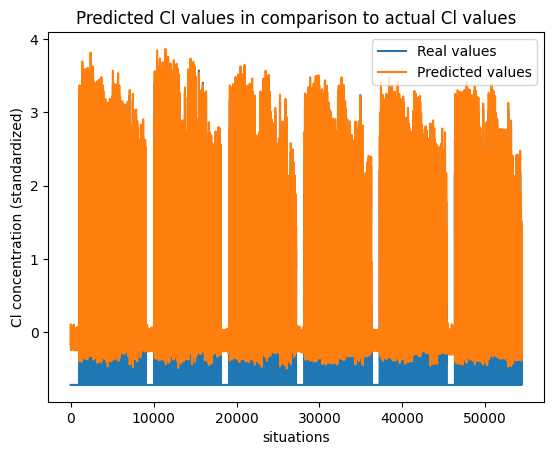

In [25]:
situations = np.array(list(range(len(real_vals_cl_bias))))
plt.plot(situations ,np.array(real_vals_cl_bias), label ="Real values")
plt.plot(situations, np.array(pred_vals_cl_bias), label = "Predicted values")

plt.xlabel("situations")
plt.ylabel("Cl concentration (standardized)")
plt.title("Predicted Cl values in comparison to actual Cl values")
plt.legend()
plt.show()

# Evaluation
- Top part of the diagram looks better, bottom part does not
- Results seem to show no significant improvement
- Conclusion: Bias term alone will not fix the regression

- Next step: Find appropriate threshold, try again